# Credit Card Default Prediction Model
### Fifth Third Bank — Take-Home Interview Assignment
**Author:** Anil Meda  
**Date:** April 2026

---

**Objective:** Build a credit decisioning model to predict which applicants will default within 12 months of card opening. The model should balance predictive power with explainability and real-world practicality.

**Key question to answer:** Should Fifth Third Bank deploy this model to make future credit decisions?

## 1. Setup & Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from scipy.stats import ks_2samp
import pickle

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

In [22]:
file_a = pd.read_csv('/Users/anilmeda/Desktop/fifth third/interview homework file A.csv')
file_b = pd.read_csv('/Users/anilmeda/Desktop/fifth third/interview homework file B.csv')

print(f'File A: {file_a.shape[0]:,} rows | {file_a.shape[1]} columns')
print(f'File B: {file_b.shape[0]:,} rows | {file_b.shape[1]} columns')
display(file_a.head(3))
display(file_b[['ID','AGE','MONTHLY_INCOME','ANNUAL_INCOME','MAJORDRG','MINORDRG','OWNRENT']].head(3))

File A: 13,444 rows | 5 columns
File B: 13,721 rows | 35 columns


,ID,DEFAULT,CARDHLDR,SPENDING,APPLICATION_DATE
0,528199--953,0,1,103.0623929,2022-09-01
1,989446--330,0,1,95.4249982,2022-06-01
2,687594--341,0,1,117.4366754,2023-05-01


,ID,AGE,MONTHLY_INCOME,ANNUAL_INCOME,MAJORDRG,MINORDRG,OWNRENT
0,737177,27.250000,1200.000000,14400.0,0,0,0
1,953898,40.833332,4000.000000,48000.0,0,0,1
2,793481,37.666668,3666.666667,44000.0,0,0,1


## 3. Data Quality Assessment

The instructions explicitly noted the data may not be clean. I reviewed both files carefully before modeling.

In [3]:
print('=== FILE A ===')
print(f'Total applications:       {len(file_a):,}')
print(f'Approved (CARDHLDR=1):    {(file_a["CARDHLDR"]==1).sum():,}')
print(f'Rejected (CARDHLDR=0):    {(file_a["CARDHLDR"]==0).sum():,}')
print(f'Blank SPENDING values:    {(file_a["SPENDING"].astype(str).str.strip()=="").sum():,}')
print(f'Overall default rate:     {file_a["DEFAULT"].mean():.1%}')

print('\n=== FILE B ===')
print(f'Records with AGE < 18:    {(file_b["AGE"] < 18).sum()}')
print(f'Records with AGE = 0:     {(file_b["AGE"] == 0).sum()}')
print(f'birth_year > 2008:        {(file_b["birth_year"] > 2008).sum()}')
redundant = ((file_b['MONTHLY_INCOME']*12).round(0) == file_b['ANNUAL_INCOME'].round(0)).all()
print(f'MONTHLY x12 == ANNUAL:    {redundant} (columns are perfectly redundant)')

=== FILE A ===
Total applications:       13,444
Approved (CARDHLDR=1):    10,499
Rejected (CARDHLDR=0):    2,945
Blank SPENDING values:    2,945
Overall default rate:     7.4%

=== FILE B ===
Records with AGE < 18:    58
Records with AGE = 0:     13
birth_year > 2008:        58
MONTHLY x12 == ANNUAL:    True (columns are perfectly redundant)


### Data Quality Decisions

| Issue | Decision | Rationale |
|---|---|---|
| CARDHLDR=0 (2,945 rejected applicants) | **Remove** | They never got a card — their DEFAULT=0 is not a real outcome, it would introduce label noise |
| AGE < 18 (58 records) | **Remove** | Cannot legally hold a credit card — data entry errors |
| Blank SPENDING | **Resolved** by removing CARDHLDR=0 | Only rejected applicants have blank spending |
| MONTHLY_INCOME redundant | **Drop** | MONTHLY_INCOME * 12 = ANNUAL_INCOME exactly for all rows |
| birth_year vs AGE | **Drop birth_year** | AGE already captures this information |
| ID format mismatch | **Parse File A** | File A: `528199--953`, File B: `528199` — extract numeric portion |
| SPENDING post-issuance | **Exclude from model** | Not known at application time — using it would be data leakage |

## 4. Data Cleaning & Joining

In [15]:
# Keep approved applicants only
fa = file_a[file_a['CARDHLDR'] == 1].copy()
fa['SPENDING'] = pd.to_numeric(fa['SPENDING'], errors='coerce')
print(f'Approved applicants: {len(fa):,} | Default rate: {fa["DEFAULT"].mean():.1%}')

# Parse ID for joining
fa['ID_join'] = fa['ID'].str.split('--').str[0].astype(int)

# Join files
df = fa.merge(file_b, left_on='ID_join', right_on='ID', how='inner')
df = df.drop_duplicates(subset=['ID_join'])
print(f'After join: {len(df):,} rows')

# Remove minors
before = len(df)
df = df[df['AGE'] >= 18].copy()
print(f'Removed {before - len(df)} underage records')

# Extract application year as a feature
df['APP_YEAR'] = pd.to_datetime(df['APPLICATION_DATE']).dt.year

# Drop redundant and identifier columns
df.drop(columns=['ID_x','ID_y','ID_join','CARDHLDR','MONTHLY_INCOME','birth_year','APPLICATION_DATE'], inplace=True)

print(f'\nFinal dataset: {df.shape[0]:,} rows | {df.shape[1]} columns')
print(f'Final default rate: {df["DEFAULT"].mean():.1%}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

Approved applicants: 10,499 | Default rate: 9.5%
After join: 10,499 rows
Removed 36 underage records

Final dataset: 10,463 rows | 35 columns
Final default rate: 9.5%
Remaining nulls: 0


## 5. Exploratory Data Analysis

In [16]:
print('=== KEY EDA FINDINGS ===')
print(f"Default rate: {df['DEFAULT'].mean():.1%} ({df['DEFAULT'].sum():,} defaulters out of {len(df):,} approved applicants)")

print(f"\nDefault rate by homeownership:")
own = df.groupby('OWNRENT')['DEFAULT'].mean()
print(f"  Renter: {own[0]:.1%} | Homeowner: {own[1]:.1%}")

print(f"\nDefault rate by self-employment:")
se = df.groupby('SELFEMPL')['DEFAULT'].mean()
print(f"  Employed: {se[0]:.1%} | Self-employed: {se[1]:.1%}")

print(f"\nMedian annual income — No Default: ${df[df['DEFAULT']==0]['ANNUAL_INCOME'].median():,.0f}")
print(f"Median annual income — Default:    ${df[df['DEFAULT']==1]['ANNUAL_INCOME'].median():,.0f}")

print(f"\nMedian age — No Default: {df[df['DEFAULT']==0]['AGE'].median():.0f} yrs")
print(f"Median age — Default:    {df[df['DEFAULT']==1]['AGE'].median():.0f} yrs")

# Feature correlation with DEFAULT
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corrwith(df['DEFAULT']).abs().drop('DEFAULT').sort_values(ascending=False)
print(f"\nTop feature correlations with DEFAULT:")
print(corr.head(8).apply(lambda x: f'{x:.4f}').to_string())
print("\n>> IMPORTANT: All correlations are below 0.05.")
print(">> Individual features have very weak signal — a key finding for the recommendation.")

=== KEY EDA FINDINGS ===
Default rate: 9.5% (992 defaulters out of 10,463 approved applicants)

Default rate by homeownership:
  Renter: 10.0% | Homeowner: 8.9%

Default rate by self-employment:
  Employed: 9.5% | Self-employed: 9.7%

Median annual income — No Default: $27,000
Median annual income — Default:    $25,000

Median age — No Default: 32 yrs
Median age — Default:    30 yrs

Top feature correlations with DEFAULT:
SPENDING          0.0486
ANNUAL_INCOME     0.0383
MINORDRG_lag12    0.0205
AGE               0.0204
MINORDRG_lag2     0.0175
OWNRENT           0.0174
MINORDRG_lag3     0.0149
MAJORDRG_lag5     0.0138

>> IMPORTANT: All correlations are below 0.05.
>> Individual features have very weak signal — a key finding for the recommendation.


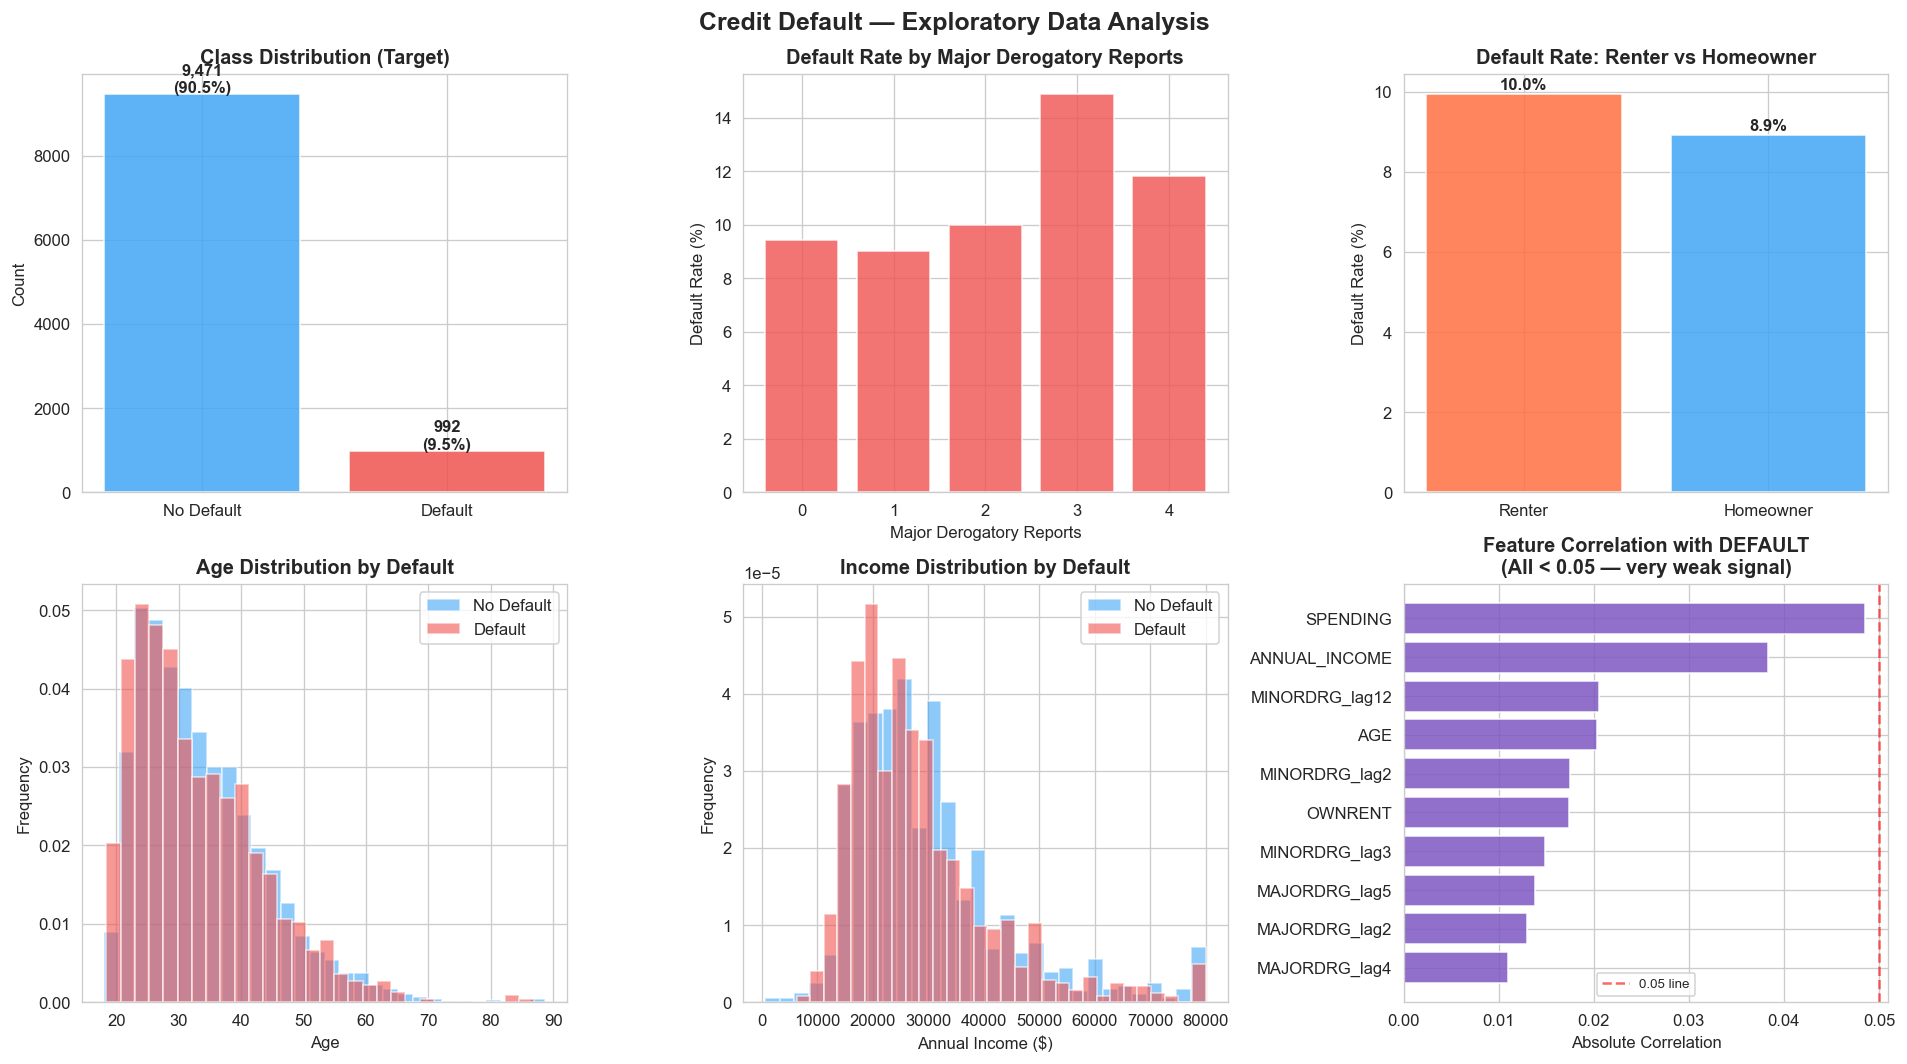

EDA charts saved.


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Credit Default — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# 1. Class imbalance
ax = axes[0, 0]
counts = df['DEFAULT'].value_counts()
bars = ax.bar(['No Default', 'Default'], counts.values, color=['#42A5F5','#EF5350'], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Class Distribution (Target)', fontweight='bold')
ax.set_ylabel('Count')

# 2. Default rate by MAJORDRG
ax = axes[0, 1]
md = df[df['MAJORDRG']<=4].groupby('MAJORDRG')['DEFAULT'].mean()*100
ax.bar(md.index.astype(str), md.values, color='#EF5350', alpha=0.8, edgecolor='white')
ax.set_title('Default Rate by Major Derogatory Reports', fontweight='bold')
ax.set_xlabel('Major Derogatory Reports')
ax.set_ylabel('Default Rate (%)')

# 3. Renter vs Homeowner
ax = axes[0, 2]
own_rate = df.groupby('OWNRENT')['DEFAULT'].mean()*100
bars = ax.bar(['Renter','Homeowner'], own_rate.values, color=['#FF7043','#42A5F5'], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, own_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Default Rate: Renter vs Homeowner', fontweight='bold')
ax.set_ylabel('Default Rate (%)')

# 4. Age distribution
ax = axes[1, 0]
df[df['DEFAULT']==0]['AGE'].plot.hist(bins=30, ax=ax, alpha=0.6, color='#42A5F5', label='No Default', density=True)
df[df['DEFAULT']==1]['AGE'].plot.hist(bins=30, ax=ax, alpha=0.6, color='#EF5350', label='Default', density=True)
ax.set_title('Age Distribution by Default', fontweight='bold')
ax.set_xlabel('Age')
ax.legend()

# 5. Income distribution
ax = axes[1, 1]
df[df['DEFAULT']==0]['ANNUAL_INCOME'].clip(upper=80000).plot.hist(bins=30, ax=ax, alpha=0.6, color='#42A5F5', label='No Default', density=True)
df[df['DEFAULT']==1]['ANNUAL_INCOME'].clip(upper=80000).plot.hist(bins=30, ax=ax, alpha=0.6, color='#EF5350', label='Default', density=True)
ax.set_title('Income Distribution by Default', fontweight='bold')
ax.set_xlabel('Annual Income ($)')
ax.legend()

# 6. Feature correlations
ax = axes[1, 2]
top_corr = corr.head(10).sort_values()
ax.barh(top_corr.index, top_corr.values, color='#7E57C2', alpha=0.85, edgecolor='white')
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.6, label='0.05 line')
ax.set_title('Feature Correlation with DEFAULT\n(All < 0.05 — very weak signal)', fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_charts.png', bbox_inches='tight', dpi=150)
plt.show()
print('EDA charts saved.')

## 6. Feature Engineering

In [18]:
# Summarize 24 monthly lag columns into 4 meaningful features
# This reduces noise and makes the model more interpretable
df['MAJORDRG_recent3'] = df[[f'MAJORDRG_lag{i}' for i in range(1,4)]].sum(axis=1)
df['MAJORDRG_old9']    = df[[f'MAJORDRG_lag{i}' for i in range(4,13)]].sum(axis=1)
df['MINORDRG_recent3'] = df[[f'MINORDRG_lag{i}' for i in range(1,4)]].sum(axis=1)
df['MINORDRG_old9']    = df[[f'MINORDRG_lag{i}' for i in range(4,13)]].sum(axis=1)

# Income per dependent — proxy for financial stress
df['INCOME_PER_DEP'] = df['ANNUAL_INCOME'] / (df['ADEPCNT'] + 1)


print('Feature engineering complete.')

Feature engineering complete.


## 7. Model Training

Two models compared:
- **XGBoost** — better-performing model (higher AUC and KS); captures non-linear patterns and handles class imbalance well via `scale_pos_weight`
- **Logistic Regression** — kept as secondary model for ECOA/Reg B regulatory explainability; its coefficients are required for adverse action notices, not because it outperforms XGBoost

Class weights / `scale_pos_weight` used for both to handle 9.5% default rate imbalance.

In [19]:
# SPENDING excluded — post-issuance data, not available at application time (data leakage)
lag_cols = [f'MAJORDRG_lag{i}' for i in range(1,13)] + [f'MINORDRG_lag{i}' for i in range(1,13)]
EXCLUDE = ['DEFAULT', 'SPENDING'] + lag_cols
features = [c for c in df.columns if c not in EXCLUDE]

X = df[features].fillna(df[features].median(numeric_only=True))
y = df['DEFAULT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

neg, pos = (y_train==0).sum(), (y_train==1).sum()
scale_pos = neg / pos

print(f'Features ({len(features)}): {features}')
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Default rate — Train: {y_train.mean():.1%} | Test: {y_test.mean():.1%}')
print(f'Class imbalance ratio: {scale_pos:.1f}:1')

# Logistic Regression
lr_model = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))])
lr_model.fit(X_train, y_train)
lr_probs = lr_model.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_probs)

# XGBoost
xgb_model = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos, subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, random_state=RANDOM_STATE, verbosity=0, eval_metric='auc')
xgb_model.fit(X_train, y_train)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_probs)

ks_lr,  _ = ks_2samp(lr_probs[y_test==0],  lr_probs[y_test==1])
ks_xgb, _ = ks_2samp(xgb_probs[y_test==0], xgb_probs[y_test==1])

print(f'\n=== Results ===')
print(f'{"Model":<25} {"AUC":>8} {"KS":>8}')
print('-'*43)
print(f'{"Logistic Regression":<25} {lr_auc:>8.4f} {ks_lr:>8.4f}')
print(f'{"XGBoost":<25} {xgb_auc:>8.4f} {ks_xgb:>8.4f}')
print(f'{"Random Baseline":<25} {0.5000:>8.4f} {0.0000:>8.4f}')
print('\nIndustry benchmarks: AUC > 0.70 | KS > 0.30')

Features (14): ['AGE', 'ACADMOS', 'ADEPCNT', 'MAJORDRG', 'MINORDRG', 'OWNRENT', 'SELFEMPL', 'ANNUAL_INCOME', 'APP_YEAR', 'MAJORDRG_recent3', 'MAJORDRG_old9', 'MINORDRG_recent3', 'MINORDRG_old9', 'INCOME_PER_DEP']
Train: 8,370 | Test: 2,093
Default rate — Train: 9.5% | Test: 9.5%
Class imbalance ratio: 9.5:1

=== Results ===
Model                          AUC       KS
-------------------------------------------
Logistic Regression         0.5061   0.0646
XGBoost                     0.5237   0.0799
Random Baseline             0.5000   0.0000

Industry benchmarks: AUC > 0.70 | KS > 0.30


## 8. Evaluation Charts

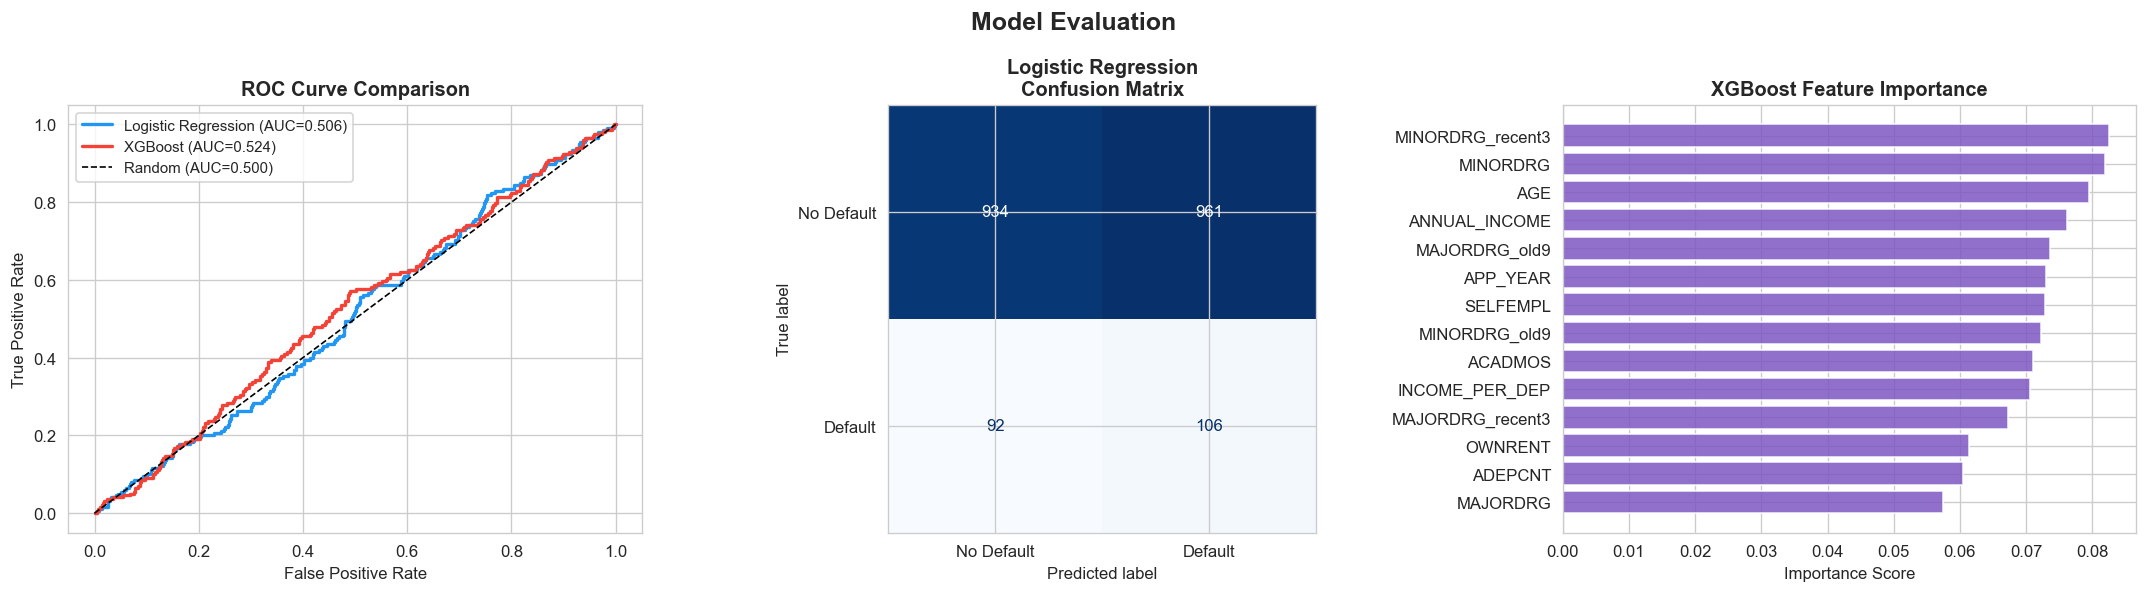

=== Logistic Regression ===
              precision    recall  f1-score   support

  No Default       0.91      0.49      0.64      1895
     Default       0.10      0.54      0.17       198

    accuracy                           0.50      2093
   macro avg       0.50      0.51      0.40      2093
weighted avg       0.83      0.50      0.59      2093

=== XGBoost ===
              precision    recall  f1-score   support

  No Default       0.91      0.69      0.79      1895
     Default       0.10      0.34      0.16       198

    accuracy                           0.66      2093
   macro avg       0.51      0.52      0.47      2093
weighted avg       0.83      0.66      0.73      2093



In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation', fontsize=15, fontweight='bold')

# ROC Curves
ax = axes[0]
for probs, label, color in [
    (lr_probs,  f'Logistic Regression (AUC={lr_auc:.3f})',  '#2196F3'),
    (xgb_probs, f'XGBoost (AUC={xgb_auc:.3f})',             '#F44336')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=label, lw=2, color=color)
ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontweight='bold')
ax.legend(fontsize=9)

# Confusion Matrix — LR
ax = axes[1]
lr_preds = (lr_probs >= 0.5).astype(int)
cm = confusion_matrix(y_test, lr_preds)
ConfusionMatrixDisplay(cm, display_labels=['No Default','Default']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression\nConfusion Matrix', fontweight='bold')

# XGBoost Feature Importance
ax = axes[2]
fi = pd.DataFrame({'Feature': features, 'Importance': xgb_model.feature_importances_}).sort_values('Importance')
ax.barh(fi['Feature'], fi['Importance'], color='#7E57C2', alpha=0.85, edgecolor='white')
ax.set_title('XGBoost Feature Importance', fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

# Classification Reports
print('=== Logistic Regression ===')
print(classification_report(y_test, lr_preds, target_names=['No Default','Default']))
xgb_preds = (xgb_probs >= 0.5).astype(int)
print('=== XGBoost ===')
print(classification_report(y_test, xgb_preds, target_names=['No Default','Default']))

## 9. Logistic Regression Coefficients

For a credit model, we need to explain *why* someone was declined — a legal requirement under ECOA/Regulation B. Logistic Regression coefficients give us that directly.

> ⚠️ **Collinearity Warning — Coefficients Cannot Be Used As-Is for Adverse Action Notices**
>
> The features include both **annual totals** (`MAJORDRG`, `MINORDRG`) and **lag summaries** (`MAJORDRG_recent3`, `MAJORDRG_old9`, `MINORDRG_recent3`, `MINORDRG_old9`) which are highly collinear — the lag summaries are partial sums of the same underlying monthly data.
> This collinearity causes **coefficient sign instability**: for example, `MINORDRG_recent3` shows a negative coefficient, implying more recent derogatory reports *reduce* default risk — which is economically nonsensical and legally indefensible under ECOA/Reg B.
>
> **To resolve before using for adverse action notices:**
> - Run VIF (Variance Inflation Factor) analysis and drop features with VIF > 5
> - Either keep the **annual totals** (`MAJORDRG`, `MINORDRG`) OR the **lag summaries** — not both
> - Refit LR on the reduced, non-collinear feature set and verify all signs are economically logical

Positive coefficient = increases default risk
Negative coefficient = decreases default risk

         Feature  Coefficient
MINORDRG_recent3    -0.109094
  INCOME_PER_DEP    -0.104323
   ANNUAL_INCOME    -0.103704
   MINORDRG_old9     0.100731
         ADEPCNT    -0.076105
        APP_YEAR     0.064370
MAJORDRG_recent3    -0.033888
        MINORDRG     0.028088
             AGE    -0.025748
         OWNRENT     0.022193
        SELFEMPL     0.021395
   MAJORDRG_old9     0.010999
        MAJORDRG    -0.010330
         ACADMOS    -0.008662


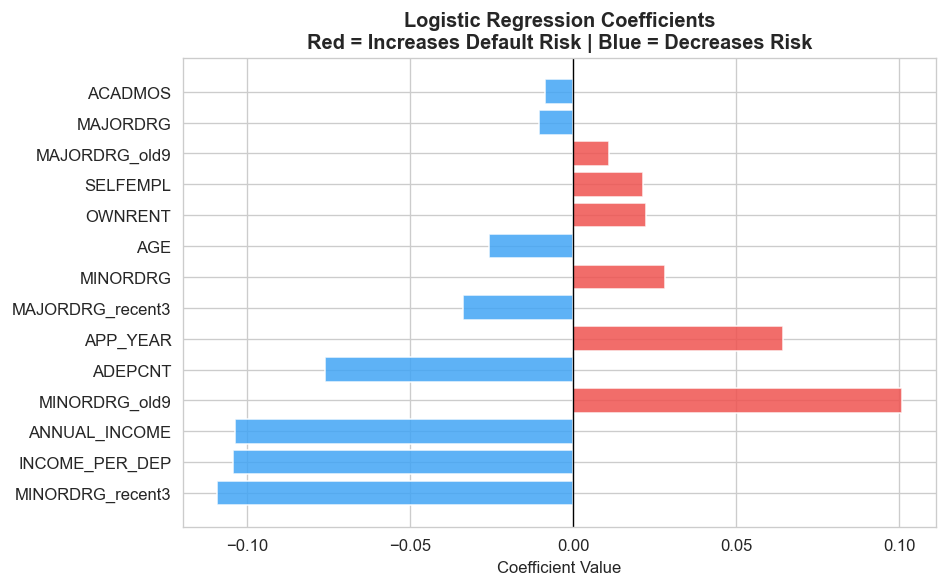

In [21]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.named_steps['clf'].coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print('Positive coefficient = increases default risk')
print('Negative coefficient = decreases default risk')
print()
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#EF5350' if c > 0 else '#42A5F5' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(x=0, color='black', lw=0.8)
ax.set_title('Logistic Regression Coefficients\nRed = Increases Default Risk | Blue = Decreases Risk', fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Deployment Recommendation

### ❌ Recommendation: Do NOT Deploy as a Standalone Credit Decisioning Model

In [11]:
print(f"""
=================================================================
DEPLOYMENT RECOMMENDATION: DO NOT DEPLOY (Standalone)
=================================================================

PERFORMANCE SUMMARY:
  XGBoost AUC             : {xgb_auc:.4f}  (benchmark: >0.70)  ← best model
  Logistic Regression AUC : {lr_auc:.4f}  (benchmark: >0.70)
  KS Statistic (XGBoost)  : {ks_xgb:.4f}  (benchmark: >0.30)
  KS Statistic (LR)       : {ks_lr:.4f}  (benchmark: >0.30)
  Random baseline         : 0.5000

MODEL ROLES:
  XGBoost wins on predictive performance (AUC {xgb_auc:.4f} vs LR {lr_auc:.4f}).
  Logistic Regression is retained solely for regulatory explainability —
  its coefficients are required for ECOA/Reg B adverse action notices.
  However, LR coefficient signs are currently unstable due to collinearity
  (see Section 9) and cannot be used for adverse action notices as-is.

WHY NOT DEPLOY:
  Both models are only marginally better than random chance.
  A model at AUC ~0.52 is NOT reliable enough for consequential
  credit decisions that affect customers' financial access.

ROOT CAUSE — A Data Problem, Not a Modeling Problem:
  All features in this dataset correlate below 0.05 with default.
  The dataset lacks the strongest predictors of credit risk:
    - Credit bureau score (FICO / VantageScore)
    - Total outstanding debt and utilization rate
    - Payment history across all accounts
    - Length of credit history
    - Recent hard inquiries

RECOMMENDED PATH FORWARD:
  1. Enrich with bureau data — even one FICO variable would likely
     lift AUC to 0.70+ based on industry benchmarks.

  2. Use as supplementary signal — this model can help rank-order
     risk tiers to assist human underwriters, not replace them.

  3. Resolve LR collinearity — run VIF analysis and drop either the
     annual totals (MAJORDRG/MINORDRG) OR the lag summaries, so LR
     coefficients become trustworthy for adverse action notices.

  4. Expand training data — include more application years and
     post-2023 economic conditions for more robust training.

  5. Re-evaluate after enrichment — XGBoost architecture is solid
     and ready to scale once better inputs are available.

BUSINESS RISK OF DEPLOYING AS-IS:
  - Wrongful rejections of creditworthy applicants (revenue loss)
  - Higher-than-expected defaults (financial loss)
  - Regulatory exposure: CFPB / ECOA scrutiny on a weak model
=================================================================
""")


DEPLOYMENT RECOMMENDATION: DO NOT DEPLOY (Standalone)

PERFORMANCE SUMMARY:
  XGBoost AUC             : 0.5237  (benchmark: >0.70)  ← best model
  Logistic Regression AUC : 0.5061  (benchmark: >0.70)
  KS Statistic (XGBoost)  : 0.0799  (benchmark: >0.30)
  KS Statistic (LR)       : 0.0646  (benchmark: >0.30)
  Random baseline         : 0.5000

MODEL ROLES:
  XGBoost wins on predictive performance (AUC 0.5237 vs LR 0.5061).
  Logistic Regression is retained solely for regulatory explainability —
  its coefficients are required for ECOA/Reg B adverse action notices.
  However, LR coefficient signs are currently unstable due to collinearity
  (see Section 9) and cannot be used for adverse action notices as-is.

WHY NOT DEPLOY:
  Both models are only marginally better than random chance.
  A model at AUC ~0.52 is NOT reliable enough for consequential
  credit decisions that affect customers' financial access.

ROOT CAUSE — A Data Problem, Not a Modeling Problem:
  All features in this dat

In [23]:
# Save models
with open('lr_credit_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('xgb_credit_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
with open('model_features.pkl', 'wb') as f:
    pickle.dump(features, f)

print('All models saved.')
print(f'Logistic Regression AUC : {lr_auc:.4f}')
print(f'XGBoost AUC             : {xgb_auc:.4f}')
print(f'Deployment decision     : NOT RECOMMENDED — data enrichment required first')

All models saved.
Logistic Regression AUC : 0.5061
XGBoost AUC             : 0.5237
Deployment decision     : NOT RECOMMENDED — data enrichment required first
